## Notes

Want economic analysis function perhaps?

If price is low - buy electricity to charge battery
If price is low and PV output is high --> charge battery
If price is high and PV output is high --> straight to grid and dispatch battery


In [131]:
import pandas as pd
import numpy as np
import cvxpy as cp
import matplotlib.pyplot as plt

In [80]:
price_data = pd.read_csv("Sylmar RTM LMP Data.csv")
prices = price_data['VALUE']

In [81]:
solar_generation = pd.read_csv('Symlar_pvwatts_hourly.csv')
# "Month","Day","Hour",
# "Beam Irradiance (W/m2)","Diffuse Irradiance (W/m2)",
# "Ambient Temperature (C)","Wind Speed (m/s)","Albedo","Plane of Array Irradiance (W/m2)",
# "Cell Temperature (C)",
# "DC Array Output (W)","AC System Output (W)"

solar_output = pd.DataFrame()
solar_output["Year 1"] = solar_generation["AC System Output (W)"]

In [82]:
# Calculate the solar output over the 30 year period for the degredation
lifespan = 30
panel_degredation = 0.005 # /yr
om_escalation = 0.01 # % /yr


### CASE 1

In [152]:
# Battery Specifications

Bat_capex =  1950.27 # $/kW
Bat_OM =  48.643 # $/kW-yr
Bat_LCOE = 4144.345  # $/MWh

SGIP = 0.85 # $/Wh
ITC = 0 # % of installation cost

bat_cap = 1000 # kW



In [153]:
P_max = 1.0 # MW
E_max = 4.0 # MWh
eta_c = 0.95
eta_d = 0.95
SOC_0 = 0.5 * E_max
soc_min = 0.1 * E_max
dt = 1/12
H = 288


In [154]:
import cvxpy as cp
import numpy as np

T = 12
x = cp.Variable(T, nonneg=True)
price = cp.Parameter(T, value=np.ones(T))

prob = cp.Problem(
    cp.Maximize(cp.sum(price * x)),
    [x <= 1]
)

prob.solve(solver=cp.OSQP)
print("Solved OK")


Solved OK


/Users/badynmilstein-touesnard/.julia/conda/3/aarch64/lib/python3.12/site-packages/cvxpy/expressions/expression.py:683: UserWarning: 
This use of ``*`` has resulted in matrix multiplication.
Using ``*`` for matrix multiplication has been deprecated since CVXPY 1.1.
    Use ``*`` for matrix-scalar and vector-scalar multiplication.
    Use ``@`` for matrix-matrix and matrix-vector multiplication.
    Use ``multiply`` for elementwise multiplication.
This code path has been hit 3 times so far.

  warnings.warn(msg, UserWarning)


In [ ]:
# Maximizing daily revenue

H = 288                 # 1 day horizon (5-min data)
dt = 5 / 60
soc_init = SOC_0        # initial SOC (MWh)
price_base = prices.mean()   # OK to compute once
P_base = P_max
E_base = E_max


results = []

# ROLLING HORIZON LOOP
for start in range(0, len(prices) - H, H):

    prices_h = prices.iloc[start:start + H].to_numpy()
    price_scaled = prices_h / price_base   # numpy array, length H

    charge = cp.Variable(H)
    discharge = cp.Variable(H)
    soc = cp.Variable(H)

    # Constraints
    constraints = [
        soc[0] == soc_init / E_base,

        soc[1:] <= soc[:-1]
            + (charge[:-1] * eta_c * dt) / E_base
            - (discharge[:-1] / eta_d * dt) / E_base,

        soc[1:] >= soc[:-1]
            + (charge[:-1] * eta_c * dt) / E_base
            - (discharge[:-1] / eta_d * dt) / E_base,

        soc >= 0,
        soc <= 1,

        charge >= 0,
        discharge >= 0,
        charge <= 1,
        discharge <= 1,
    ]

    # Objective
    objective = cp.Maximize(
        cp.sum(
            cp.multiply(prices_h, (discharge * P_base * eta_d - charge * P_base / eta_c)) * dt
        )
    ) 


    # Solve
    problem = cp.Problem(objective, constraints)
    problem.solve(solver=cp.OSQP)


    results.append({
        "charge": charge.value,
        "discharge": discharge.value,
        "soc": soc.value,
        "start_index": start,
    })

    soc_init = soc.value[-1] * E_base


/Users/badynmilstein-touesnard/.julia/conda/3/aarch64/lib/python3.12/site-packages/cvxpy/problems/problem.py:1539: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  warnings.warn(


In [87]:
print(type(prices.index))
print(prices.index[:5])


<class 'pandas.core.indexes.range.RangeIndex'>
RangeIndex(start=0, stop=5, step=1)


In [88]:
start_time = "2023-01-01 00:00"  # choose your dataset start
freq = "5T"  # 5-minute intervals

prices.index = pd.date_range(start=start_time, periods=len(prices), freq=freq)

/var/folders/w9/vwctfdqs0v11qkc_klj078540000gn/T/ipykernel_97230/1597950459.py:4: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  prices.index = pd.date_range(start=start_time, periods=len(prices), freq=freq)


In [89]:
time_index = prices.index[:len(prices) - H]

charge_all = np.concatenate([r["charge"] for r in results])
discharge_all = np.concatenate([r["discharge"] for r in results])
soc_all = np.concatenate([r["soc"] for r in results])

dispatch = pd.DataFrame(
    {
        "price": prices.iloc[:len(charge_all)],
        "charge_MW": charge_all * P_base,
        "discharge_MW": discharge_all * P_base,
        "SOC_MWh": soc_all * E_base,
    },
    index=prices.index[:len(charge_all)]
)

dispatch["charge_MWh"] = dispatch["charge_MW"] * dt
dispatch["discharge_MWh"] = dispatch["discharge_MW"] * dt


In [90]:
dispatch["charge_cost_$"] = (
    dispatch["charge_MWh"] / eta_c
) * dispatch["price"]

dispatch["discharge_revenue_$"] = (
    dispatch["discharge_MWh"] * eta_d
) * dispatch["price"]

dispatch["net_revenue_$"] = (
    dispatch["discharge_revenue_$"]
    - dispatch["charge_cost_$"]
)


In [91]:
cycle_cost_per_MWh = 5  # $/MWh for degredation 

dispatch["degradation_$"] = (
    dispatch["charge_MWh"] + dispatch["discharge_MWh"]
) * cycle_cost_per_MWh

dispatch["net_revenue_after_deg_$"] = (
    dispatch["net_revenue_$"] - dispatch["degradation_$"]
)



In [92]:
daily = dispatch.resample("D").sum()
annual = dispatch.resample("Y").sum()
annual_revenue = annual["net_revenue_after_deg_$"].sum()


/var/folders/w9/vwctfdqs0v11qkc_klj078540000gn/T/ipykernel_97230/4249702191.py:2: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  annual = dispatch.resample("Y").sum()


In [124]:
print(annual)

                   price     charge_MW  discharge_MW        SOC_MWh  \
2023-12-31  4.599494e+06  31390.797934  28720.630254  162718.541847   

             charge_MWh  discharge_MWh  charge_cost_$  discharge_revenue_$  \
2023-12-31  2615.899828    2393.385854   66966.412128        122739.232748   

            net_revenue_$  degradation_$  net_revenue_after_deg_$  
2023-12-31   55772.820619   25046.428412             30726.392208  


In [155]:
case_1 = pd.DataFrame(
    index=range(1, lifespan + 1)
)

case_1["Yearly Bat OM"] = (
    Bat_OM
    * bat_cap
    * (1 + om_escalation) ** (case_1.index - 1)
)

#print(case_1)

In [156]:
print(case_1["Yearly Bat OM"])

1     48643.000000
2     49129.430000
3     49620.724300
4     50116.931543
5     50618.100858
6     51124.281867
7     51635.524686
8     52151.879933
9     52673.398732
10    53200.132719
11    53732.134046
12    54269.455387
13    54812.149941
14    55360.271440
15    55913.874155
16    56473.012896
17    57037.743025
18    57608.120455
19    58184.201660
20    58766.043676
21    59353.704113
22    59947.241154
23    60546.713566
24    61152.180702
25    61763.702509
26    62381.339534
27    63005.152929
28    63635.204458
29    64271.556503
30    64914.272068
Name: Yearly Bat OM, dtype: float64


In [157]:
bat_capex = Bat_capex * bat_cap * (1 - ITC)
IRR = 0.12
npv = -bat_capex

for t in range(1, 31):
    revenue_t = annual["net_revenue_after_deg_$"].sum()
    om_t = case_1["Yearly Bat OM"].iloc[t-1]
    npv += (revenue_t - om_t) / (1 + IRR)**t

print(f"NPV of the battery storage project: ${npv:,.0f}")
print(bat_capex)

NPV of the battery storage project: $-2,125,078
1950270.0


Want to look at 
• Installation Costs (ITC is here)
• Annual operating cost differences
• NPV impact of augmentation timing

### CASE 2

In [158]:
# SOLAR PARAMETERS

solar_installed_capacity = 4000  # kW
solar_capacity_factor = 0.202
duration = 4  # hours
pv_dc = solar_installed_capacity * 1000
inverter = 3000  # kW
dc_ac_ratio = solar_installed_capacity/inverter

Co_LCOE = 76.872 # $/MWh
Co_CAPEX = 1975.242 # $/kW
Co_FIXED_OM = 58.635 # $/kW-year

ac_inverter = pv_dc / dc_ac_ratio

co_cap = Co_CAPEX * solar_installed_capacity * (1 - ITC)  
print(co_cap)

7900968.0


In [159]:
years = np.arange(lifespan)
panel_degredation = 0.005 # /yr

degradation_factors = (1 - panel_degredation) ** years

yearly_output = (
    solar_output["Year 1"].sum()
    * degradation_factors
)

case_2 = pd.DataFrame(
    {"Output AC (kW)": yearly_output},
    index=range(1, lifespan + 1)
)

case_2["Yearly OM"] = (
    Co_FIXED_OM
    * solar_installed_capacity
    * (1 + om_escalation) ** (case_2.index - 1)
)

case_2["Revenue"] = (
    Co_LCOE
    * case_2["Output AC (kW)"]
)

#print(case_2)

In [110]:

P_max = 1.0 # MW
E_max = 4.0 # MWh
eta_c = 0.95
eta_d = 0.95
soc_init = 0.5 * E_max


prices = price_data['VALUE'].resample('H').mean().to_numpy()
prices = prices[:8760]  # Ensure length is 8760
# --------------------------
pv_ac_output_yr1 = solar_output["Year 1"].to_numpy() / 1000000  # Convert W to MW
deg_rate = 0.005  # 0.5% per year
num_years = 30

total_revenue = 0
output = []

for year in range(num_years):
    # Apply PV degradation
    PV = pv_ac_output_yr1 * (1 - deg_rate)**year
    H = len(PV)

    # --------------------------
    # Decision variables
    # --------------------------
    ch_pv = cp.Variable(H)    # battery charging from PV
    ch_grid = cp.Variable(H)  # battery charging from grid
    dis = cp.Variable(H)      # battery discharging
    soc = cp.Variable(H)      # state of charge
    pv_export = cp.Variable(H) # PV exported directly

    # --------------------------
    # Constraints
    # --------------------------
    constraints = []

    # Initial SOC
    constraints.append(soc[0] == soc_init)

    # SOC dynamics
    constraints += [soc[1:] == soc[:-1] + eta_c*(ch_pv[:-1] + ch_grid[:-1]) - dis[:-1]/eta_d]

    # Battery limits
    constraints += [
        soc >= 0,
        soc <= E_max,
        ch_pv >= 0, ch_pv <= P_max,
        ch_grid >= 0, ch_grid <= P_max,
        dis >= 0, dis <= P_max,
        ch_pv + ch_grid + dis <= P_max  # optional: prevent exceeding max power
    ]

    # PV constraints
    constraints += [
        pv_export >= 0,
        pv_export <= PV,
        ch_pv <= PV  # PV charging cannot exceed PV available
    ]

    # --------------------------
    # Objective function
    # --------------------------
    PTC_rate = 0.0275 * 1.2  # $/kW
    ptc_revenue = cp.sum(pv_export * 1000 * PTC_rate)  # pv_export in MW → *1000 kW
    revenue_market = cp.sum(cp.multiply(prices, pv_export + dis - ch_grid))

    # Revenue = PV export + battery discharge - grid charging cost
    revenue = revenue_market + ptc_revenue
    objective = cp.Maximize(revenue)

    # --------------------------
    # Solve optimization
    # --------------------------
    problem = cp.Problem(objective, constraints)
    problem.solve(solver=cp.OSQP)

    # --------------------------
    # Record results
    # --------------------------
    revenue_year = revenue.value
    total_revenue += revenue_year
    soc_init = soc.value[-1]  # roll SOC forward

    output.append(revenue_year)
    
    print(f"Year {year+1}: Revenue = ${revenue_year:,.0f}, PV degradation applied")

print(f"\nTotal 30-year revenue = ${total_revenue:,.0f}")


/var/folders/w9/vwctfdqs0v11qkc_klj078540000gn/T/ipykernel_97230/1284268182.py:8: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  prices = price_data['VALUE'].resample('H').mean().to_numpy()
/Users/badynmilstein-touesnard/.julia/conda/3/aarch64/lib/python3.12/site-packages/cvxpy/problems/problem.py:1539: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  warnings.warn(


Year 1: Revenue = $654,165, PV degradation applied
Year 2: Revenue = $651,457, PV degradation applied
Year 3: Revenue = $648,847, PV degradation applied
Year 4: Revenue = $646,250, PV degradation applied
Year 5: Revenue = $643,666, PV degradation applied
Year 6: Revenue = $641,094, PV degradation applied
Year 7: Revenue = $638,535, PV degradation applied
Year 8: Revenue = $635,988, PV degradation applied
Year 9: Revenue = $633,455, PV degradation applied
Year 10: Revenue = $630,933, PV degradation applied
Year 11: Revenue = $628,424, PV degradation applied
Year 12: Revenue = $625,928, PV degradation applied
Year 13: Revenue = $623,444, PV degradation applied
Year 14: Revenue = $620,972, PV degradation applied
Year 15: Revenue = $618,512, PV degradation applied
Year 16: Revenue = $616,064, PV degradation applied
Year 17: Revenue = $613,628, PV degradation applied
Year 18: Revenue = $611,205, PV degradation applied
Year 19: Revenue = $608,792, PV degradation applied
Year 20: Revenue = $6

In [76]:
print(len(output))

30


In [161]:
discount_rate = 0.12
output_array = np.array(output[:30])
om_array = np.array([case_2["Yearly OM"][year] for year in range(1, 31)])
co_cap_adjusted = co_cap * (1 - ITC)  # for 30% ITC

npv = -co_cap_adjusted
for t in range(30):
    cash_flow = output_array[t] - om_array[t]
    npv += cash_flow / (1 + discount_rate)**(t+1)

print(f"30-year NPV with 30% ITC = ${npv:,.0f}")
print(co_cap_adjusted)


30-year NPV with 30% ITC = $-4,817,956
7900968.0


ITC: 0%, NPV: $-867,472
ITC: 10%, NPV: $-472,424
ITC: 20%, NPV: $-77,376
ITC: 30%, NPV: $317,673
ITC: 40%, NPV: $712,721
ITC: 50%, NPV: $1,107,770


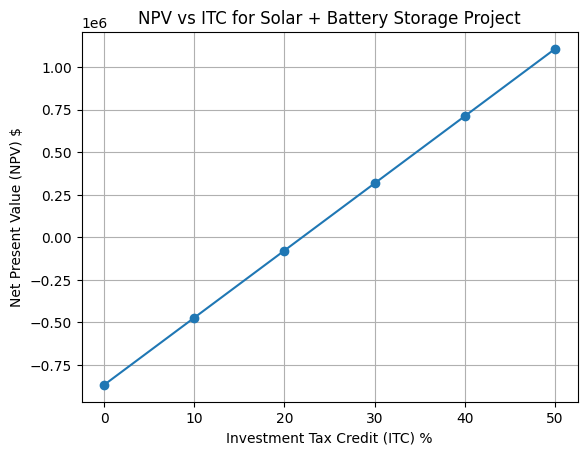

In [139]:
discount_rate = 0.12
output_array = np.array(output[:30])               # 30-year cash inflows
om_array = np.array([case_2["Yearly OM"][year] for year in range(1, 31)])  # 30-year O&M
co_cap_base = co_cap                               # original capital cost

# ITC values to test (0% to 50%)
ITC_values = np.linspace(0, 0.5, 6)
NPVs = []

for ITC in ITC_values:
    # Adjust initial investment for ITC
    co_cap_adjusted = co_cap_base * (1 - ITC)
    
    # Compute NPV
    npv = -co_cap_adjusted
    for t in range(30):  # 30 years
        cash_flow = output_array[t] - om_array[t]
        npv += cash_flow / (1 + discount_rate)**(t+1)  # discount year t+1
    
    NPVs.append(npv)

# Print results
for ITC, npv_val in zip(ITC_values, NPVs):
    print(f"ITC: {ITC*100:.0f}%, NPV: ${npv_val:,.0f}")

plt.plot(ITC_values * 100, NPVs, marker='o')
plt.xlabel('Investment Tax Credit (ITC) %')
plt.ylabel('Net Present Value (NPV) $')
plt.title('NPV vs ITC for Solar + Battery Storage Project')
plt.grid()
plt.show()


### CASE 3

In [ ]:
# case 1 but ITC = 0

### CASE 4

In [ ]:
# case 2 but ITC = 0

## Case 1 Sensitivity Analysis

[30726.39220757 30572.76024653 30419.8964453  30267.79696308
 30116.45797826 29965.87568837 29816.04630993 29666.96607838
 29518.63124799 29371.03809175 29224.18290129 29078.06198678
 28932.67167685 28788.00831846 28644.06827687 28500.84793549
 28358.34369581 28216.55197733 28075.46921744 27935.09187136
 27795.416412   27656.43932994 27518.15713329 27380.56634762
 27243.66351588 27107.4451983  26971.90797231 26837.04843245
 26702.86319029 26569.34887434]
ITC: 0%, NPV: $237,330
ITC: 10%, NPV: $237,430
ITC: 20%, NPV: $237,530
ITC: 30%, NPV: $237,630
ITC: 40%, NPV: $237,730
ITC: 50%, NPV: $237,830


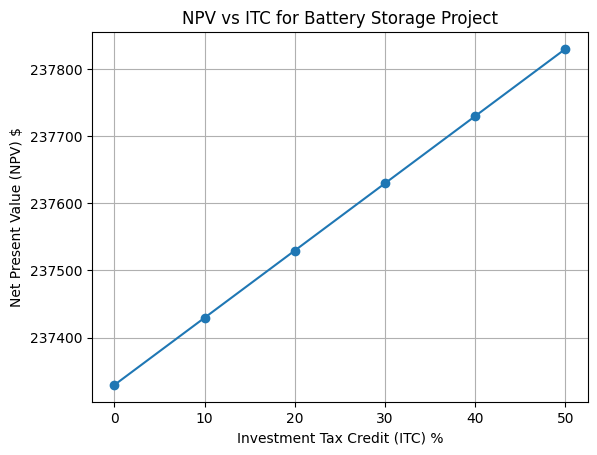

In [132]:

# Parameters
IRR = 0.12
bat_cap = 1.0  # MW
Bat_capex = 1000  # $/kW, for example
OM_annual = case_1["Yearly Bat OM"].to_numpy()  # array length 31 (Year 0 to 30)

revenues_annual = np.zeros(30)
for year in range(30):
    revenues_annual[year] = annual["net_revenue_after_deg_$"].sum() * (1 - deg_rate)**year

print(revenues_annual)
# ITC values to test (0% to 50%)
ITC_values = np.linspace(0, 0.5, 6)
NPVs = []

for ITC in ITC_values:
    # Initial CapEx after ITC
    bat_capex = Bat_capex * bat_cap * (1 - ITC)
    
    # Start NPV with -CapEx
    npv = -bat_capex
    
    # Loop over 30 years
    for t in range(1, 31):
        revenue_t = revenues_annual[t-1]  # year t revenue
        om_t = OM_annual[t-1]             # year t O&M
        npv += (revenue_t - om_t) / (1 + IRR)**t

    NPVs.append(npv)

# Print results
for ITC, npv in zip(ITC_values, NPVs):
    print(f"ITC: {ITC*100:.0f}%, NPV: ${npv:,.0f}")

plt.plot(ITC_values * 100, NPVs, marker='o')
plt.xlabel('Investment Tax Credit (ITC) %')
plt.ylabel('Net Present Value (NPV) $')
plt.title('NPV vs ITC for Battery Storage Project')
plt.grid()
plt.show()


In [162]:
## LATEX Equations

#### Parameters

$$
P_{\max} = 1.0
$$

$$
E_{\max} = 4.0
$$

$$
\eta_c = 0.95
$$

$$
\eta_d = 0.95
$$

$$
SOC_0 = 0.5 E_{\max}
$$



\[
\begin{aligned}
\pi_t &= \text{Hourly electricity price} \; [\$/\text{MWh}], \quad t = 1,\dots,8760 \\
PV^{(1)}_t &= \text{Year 1 PV AC output} \; [\text{MW}]
\end{aligned}
\]


#### Degredation

\[
\begin{aligned}
c^{pv}_t &\ge 0 && \text{Battery charging from PV (MW)} \\
c^{g}_t  &\ge 0 && \text{Battery charging from grid (MW)} \\
d_t      &\ge 0 && \text{Battery discharging (MW)} \\
\text{SOC}_t &&& \text{State of charge (MWh)} \\
e_t      &\ge 0 && \text{PV exported directly to grid (MW)}
\end{aligned}
\]


#### Battery Constraints

$$
0 \le SOC_t \le E_{\max}
$$

$$
0 \le c^{pv}_t \le P_{\max}
$$

$$
0 \le c^{g}_t \le P_{\max}
$$

$$
0 \le d_t \le P_{\max}
$$



#### Objective Funtion
$$
\max \; R = R_{market} + R_{PTC}
$$
